# Detecção de Discurso de Ódio em Português com SVM — OffComBR2

**Configurações padronizadas:**
- Dataset: OffComBR2 (formato ARFF, carregado via GitHub)
- Split: 80% treino / 20% teste, com `stratify=y` e `random_state=42`
- Pré-processamento: lowercase, remoção de URLs, menções, pontuação e números
- Métrica principal: F1-score macro

## 1. Importações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import csv
import requests

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix, f1_score

## 2. Carregamento da base de dados (formato ARFF)

In [2]:
url = 'https://raw.githubusercontent.com/rogersdepelle/OffComBR/master/OffComBR2.arff'
response = requests.get(url)
response.raise_for_status()

lines = response.text.splitlines()
data_start = next(i for i, l in enumerate(lines) if l.strip().lower() == '@data') + 1

records = []
reader = csv.reader(lines[data_start:])
for row in reader:
    if len(row) < 2:
        continue
    cls = row[0].strip()
    doc = row[1].strip().strip("'\"")
    if cls in ('yes', 'no'):
        records.append({'text': doc, 'label': 1 if cls == 'yes' else 0})

df = pd.DataFrame(records)

print(f'Total de amostras: {len(df)}')
print(f'Distribuição de classes:\n{df["label"].value_counts()}')
print(f'\nTaxa de conteúdo ofensivo: {df["label"].mean():.1%}')

Total de amostras: 1250
Distribuição de classes:
label
0    831
1    419
Name: count, dtype: int64

Taxa de conteúdo ofensivo: 33.5%


## 3. Pré-processamento de texto

In [3]:
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#\w+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), ' ', text)
    text = re.sub(r'\w*\d\w*', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['text_clean'] = df['text'].apply(preprocess_text)
df[['text', 'text_clean']].head()

,text,text_clean
0,Votaram no PEZAO Agora tomem no CZAO,votaram no pezao agora tomem no czao
1,cuidado com a poupanca pessoal Lembram o que a...,cuidado com a poupanca pessoal lembram o que a...
2,Sabe o que eu acho engracado os nossos governa...,sabe o que eu acho engracado os nossos governa...
3,os cariocas tem o que merecem um pessoal que s...,os cariocas tem o que merecem um pessoal que s...
4,Podiam retirar dos lucros dos bancos,podiam retirar dos lucros dos bancos


## 4. Vetorização com TF-IDF

In [4]:
vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['text_clean'])
y = df['label']

print(f'Dimensão do vetor TF-IDF: {X.shape}')

Dimensão do vetor TF-IDF: (1250, 10000)


## 5. Divisão treino/teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treinamento: {X_train.shape[0]} amostras')
print(f'Teste:       {X_test.shape[0]} amostras')

Treinamento: 1000 amostras
Teste:       250 amostras


## 6. Treinamento do modelo SVM

In [6]:
svm_model = LinearSVC(class_weight='balanced', random_state=42, max_iter=2000)
svm_model.fit(X_train, y_train)

LinearSVC(class_weight='balanced', max_iter=2000, random_state=42)

## 7. Avaliação do modelo

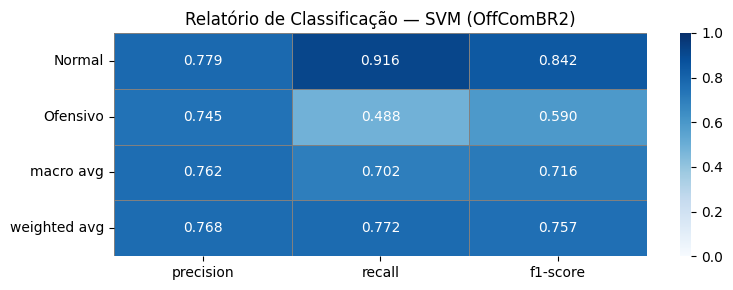

F1-score Macro: 0.7160


In [7]:
y_pred = svm_model.predict(X_test)

# Relatório de classificação como imagem
report_dict = classification_report(y_test, y_pred, target_names=['Normal', 'Ofensivo'], output_dict=True)
df_report = pd.DataFrame(report_dict).T.drop('accuracy', errors='ignore')

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(
    df_report[['precision', 'recall', 'f1-score']].astype(float),
    annot=True, fmt='.3f', cmap='Blues',
    linewidths=0.5, linecolor='gray',
    ax=ax, vmin=0, vmax=1
)
ax.set_title('Relatório de Classificação \u2014 SVM (OffComBR2)')
plt.tight_layout()
plt.savefig('report_svm_offcombr2.png', dpi=150, bbox_inches='tight')
plt.show()

f1_macro = report_dict['macro avg']['f1-score']
print(f'F1-score Macro: {f1_macro:.4f}')

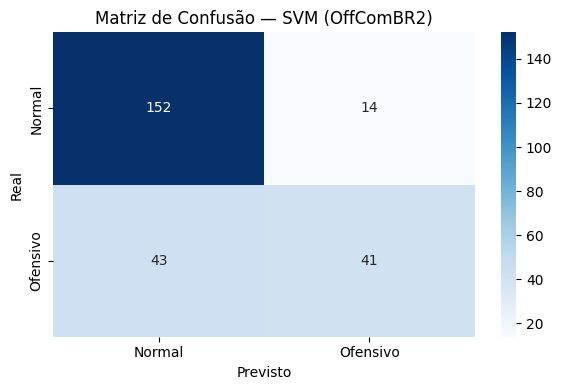

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Ofensivo'],
            yticklabels=['Normal', 'Ofensivo'])
plt.title('Matriz de Confusão — SVM (OffComBR2)')
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

## 8. Tokens mais relevantes por classe

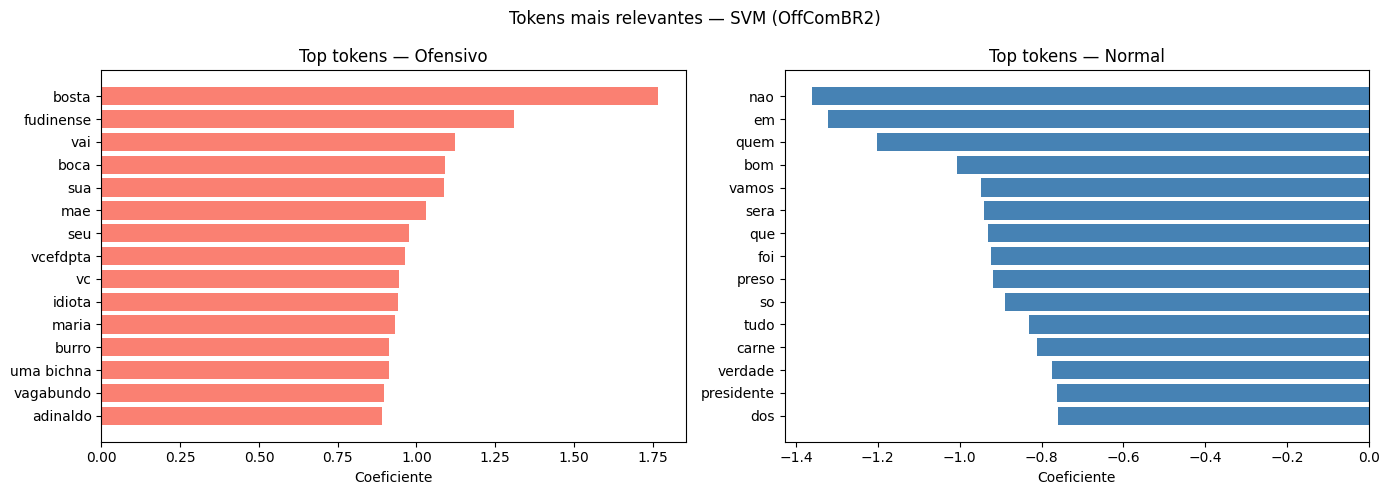

In [9]:
feature_names = vectorizer.get_feature_names_out()
coef = svm_model.coef_[0]
top_n = 15

top_off = np.argsort(coef)[-top_n:][::-1]
top_norm = np.argsort(coef)[:top_n]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(feature_names[top_off][::-1], coef[top_off][::-1], color='salmon')
axes[0].set_title('Top tokens — Ofensivo')
axes[0].set_xlabel('Coeficiente')

axes[1].barh(feature_names[top_norm][::-1], coef[top_norm][::-1], color='steelblue')
axes[1].set_title('Top tokens — Normal')
axes[1].set_xlabel('Coeficiente')

plt.suptitle('Tokens mais relevantes — SVM (OffComBR2)')
plt.tight_layout()
plt.show()

In [11]:
# ANALISE_QUALITATIVA_PATCH
import pandas as _pd, os as _os
from sklearn.model_selection import train_test_split as _tts

# Reconstrução dos textos de teste (mesmo split determinístico)
_, _idx = _tts(np.arange(len(df)), test_size=0.2,
               stratify=df['label'], random_state=42)
_texts = df['text'].values[_idx]

# Converter y_test para numpy (é pandas Series em LogReg/SVM)
_y_test = np.array(y_test)
_y_pred = np.array(y_pred)

_fp_idx = np.where((_y_test == 0) & (_y_pred == 1))[0]
_fn_idx = np.where((_y_test == 1) & (_y_pred == 0))[0]

_rng = np.random.default_rng(42)
_fp_s = _rng.choice(_fp_idx, size=min(10, len(_fp_idx)), replace=False) if len(_fp_idx) else np.array([], int)
_fn_s = _rng.choice(_fn_idx, size=min(10, len(_fn_idx)), replace=False) if len(_fn_idx) else np.array([], int)

_rows = []
for _i in _fp_s:
    _rows.append({'modelo': 'SVM', 'dataset': 'OffComBR2',
                   'tipo': 'Falso Positivo', 'texto': _texts[_i],
                   'rotulo_real': int(_y_test[_i]), 'predicao': int(_y_pred[_i])})
for _i in _fn_s:
    _rows.append({'modelo': 'SVM', 'dataset': 'OffComBR2',
                   'tipo': 'Falso Negativo', 'texto': _texts[_i],
                   'rotulo_real': int(_y_test[_i]), 'predicao': int(_y_pred[_i])})

_csv = 'analisequalitativa.csv'
_df_new = _pd.DataFrame(_rows)
if _os.path.exists(_csv):
    _df_existing = _pd.read_csv(_csv)
    _df_existing = _df_existing[
        ~((_df_existing['modelo'] == 'SVM') & (_df_existing['dataset'] == 'OffComBR2'))
    ]
    _df_new = _pd.concat([_df_existing, _df_new], ignore_index=True)
_df_new.to_csv(_csv, index=False)

texts_qualitativa = _texts

print(f'Exportados {len(_fp_s)} FP e {len(_fn_s)} FN → {_csv}')
print(f'Total no arquivo: {len(_df_new)} linhas')

Exportados 10 FP e 10 FN → analisequalitativa.csv
Total no arquivo: 200 linhas
